In [1]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
     

X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)
     

df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [2]:
df.shape


(100, 3)

In [3]:
 df.head()

,feature1,feature2,target
0,0.107808,-0.212487,56.754995
1,-0.410999,-0.621740,-13.856005
2,0.821955,0.040371,1.222546
3,-0.390508,-0.035329,4.804577
4,-0.438885,1.024338,-14.991403


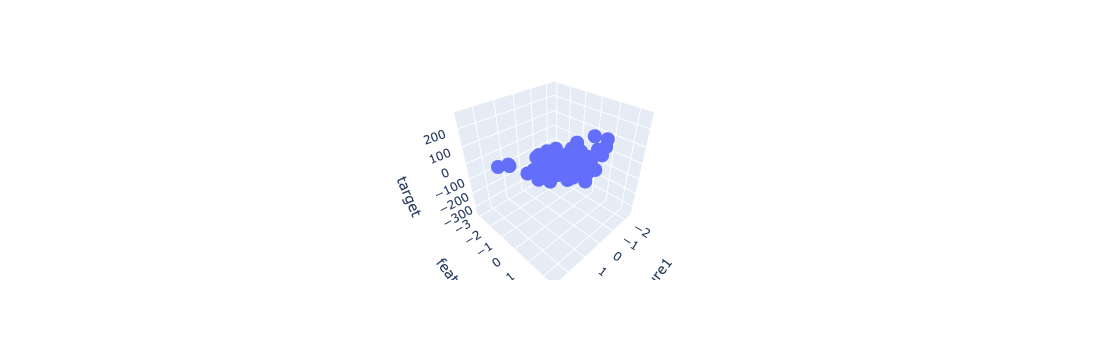

In [4]:

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)
     

from sklearn.linear_model import LinearRegression
     

lr = LinearRegression()
     

lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
y_pred = lr.predict(X_test)

In [7]:

print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 41.66701928862112
MSE 2858.4450864774285
R2 score 0.8660304549467286


In [10]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xGrid, yGrid = np.meshgrid(y, x)

# FIRST create final
final = np.vstack((
    xGrid.ravel().reshape(1,100),
    yGrid.ravel().reshape(1,100)
)).T

# THEN predict
z_final = lr.predict(final).reshape(10,10)

z = z_final

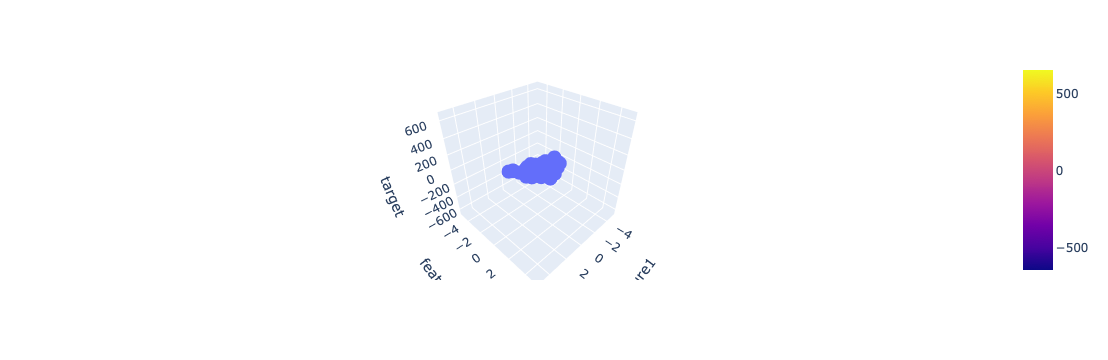

In [16]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(
    x = xGrid,
    y = yGrid,
    z = z,
    opacity=0.6
))

fig.show()

In [14]:

lr.coef_

array([56.85042789, 72.62832509])

In [15]:
lr.intercept_

np.float64(2.0240806021789792)